### CH21. 딥러닝을 이용한 자연어 처리

텍스트의 토큰화

In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
docs = ['먼저 텍스트의 각 단어를 나누어 토큰화합니다.',
'텍스트의 단어로 토큰화해야 딥러닝에서 인식됩니다.',
'토큰화한 결과는 딥러닝에서 사용할 수 있습니다.']

token = Tokenizer()
token.fit_on_texts(docs)

print('\n단어 카운트:\n', token.word_counts)


단어 카운트:
 OrderedDict({'먼저': 1, '텍스트의': 2, '각': 1, '단어를': 1, '나누어': 1, '토큰화합니다': 1, '단어로': 1, '토큰화해야': 1, '딥러닝에서': 2, '인식됩니다': 1, '토큰화한': 1, '결과는': 1, '사용할': 1, '수': 1, '있습니다': 1})


In [5]:
print('\n단어 카운트: ', token.document_count)


단어 카운트:  3


In [6]:
print('\n각 단어가 몇 개의 문장에 포함되어 있는가?:\n', token.word_docs)


각 단어가 몇 개의 문장에 포함되어 있는가?:
 defaultdict(<class 'int'>, {'텍스트의': 2, '토큰화합니다': 1, '단어를': 1, '각': 1, '나누어': 1, '먼저': 1, '딥러닝에서': 2, '토큰화해야': 1, '단어로': 1, '인식됩니다': 1, '수': 1, '결과는': 1, '사용할': 1, '토큰화한': 1, '있습니다': 1})


In [7]:
print('\n각 단어에 매겨진 인덱스 값:\n', token.word_index)


각 단어에 매겨진 인덱스 값:
 {'텍스트의': 1, '딥러닝에서': 2, '먼저': 3, '각': 4, '단어를': 5, '나누어': 6, '토큰화합니다': 7, '단어로': 8, '토큰화해야': 9, '인식됩니다': 10, '토큰화한': 11, '결과는': 12, '사용할': 13, '수': 14, '있습니다': 15}


원-핫 인코딩

In [8]:
text = '오랫동안 꿈꾸는 이는 그 꿈을 닮아간다'
token = Tokenizer()
token.fit_on_texts([text])
print(token.word_index)

{'오랫동안': 1, '꿈꾸는': 2, '이는': 3, '그': 4, '꿈을': 5, '닮아간다': 6}


In [9]:
x = token.texts_to_sequences([text])
print(x)

[[1, 2, 3, 4, 5, 6]]


In [10]:
from tensorflow.keras.utils import to_categorical

In [11]:
word_size = len(token.word_index)+1
x = to_categorical(x, num_classes = word_size)
print(x)

[[[0. 1. 0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 0. 0. 1.]]]


단어 임베딩

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Dense, Flatten
from tensorflow.keras.models import Sequential
from numpy import array

In [16]:
model = Sequential()
model.add(Embedding(16, 4))
model.build((None, 2))

텍스트 읽고 긍/부정 예측하기

In [29]:
docs = ['너무 재밌네요', '최고예요', '참 잘 만든 영화예요', '추천하고 싶은 영화입니다.', '한 번 더 보고싶네요', '글쎄요', '별로예요', '생각보다 지루하네요', '연기가 어색해요', '재미없어요']
classes = array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

token = Tokenizer()
token.fit_on_texts(docs)

print(token.word_index)

x = token.texts_to_sequences(docs)
print('\n리뷰 텍스트, 토큰화 결과:\n', x)

{'너무': 1, '재밌네요': 2, '최고예요': 3, '참': 4, '잘': 5, '만든': 6, '영화예요': 7, '추천하고': 8, '싶은': 9, '영화입니다': 10, '한': 11, '번': 12, '더': 13, '보고싶네요': 14, '글쎄요': 15, '별로예요': 16, '생각보다': 17, '지루하네요': 18, '연기가': 19, '어색해요': 20, '재미없어요': 21}

리뷰 텍스트, 토큰화 결과:
 [[1, 2], [3], [4, 5, 6, 7], [8, 9, 10], [11, 12, 13, 14], [15], [16], [17, 18], [19, 20], [21]]


In [32]:
padded_x = pad_sequences(x, 4)
print('\n패딩 결과:\n', padded_x)

word_size = len(token.word_index) + 1

model = Sequential()
model.add(Embedding(word_size, 8))
model.build((None, 4))
model.add(Flatten())
model.add(Dense(1, activation = 'sigmoid'))
model.summary()

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.fit(padded_x, classes, epochs = 20)
print('\n accuracy: %.4f' %(model.evaluate(padded_x, classes)[1]))


패딩 결과:
 [[ 0  0  1  2]
 [ 0  0  0  3]
 [ 4  5  6  7]
 [ 0  8  9 10]
 [11 12 13 14]
 [ 0  0  0 15]
 [ 0  0  0 16]
 [ 0  0 17 18]
 [ 0  0 19 20]
 [ 0  0  0 21]]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 4, 8)           │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5000 - loss: 0.6922
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6000 - loss: 0.6899
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7000 - loss: 0.6875
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8000 - loss: 0.6852
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9000 - loss: 0.6828
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.6804
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.6781
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.6757
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.6734
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.6710
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.6686
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.6663


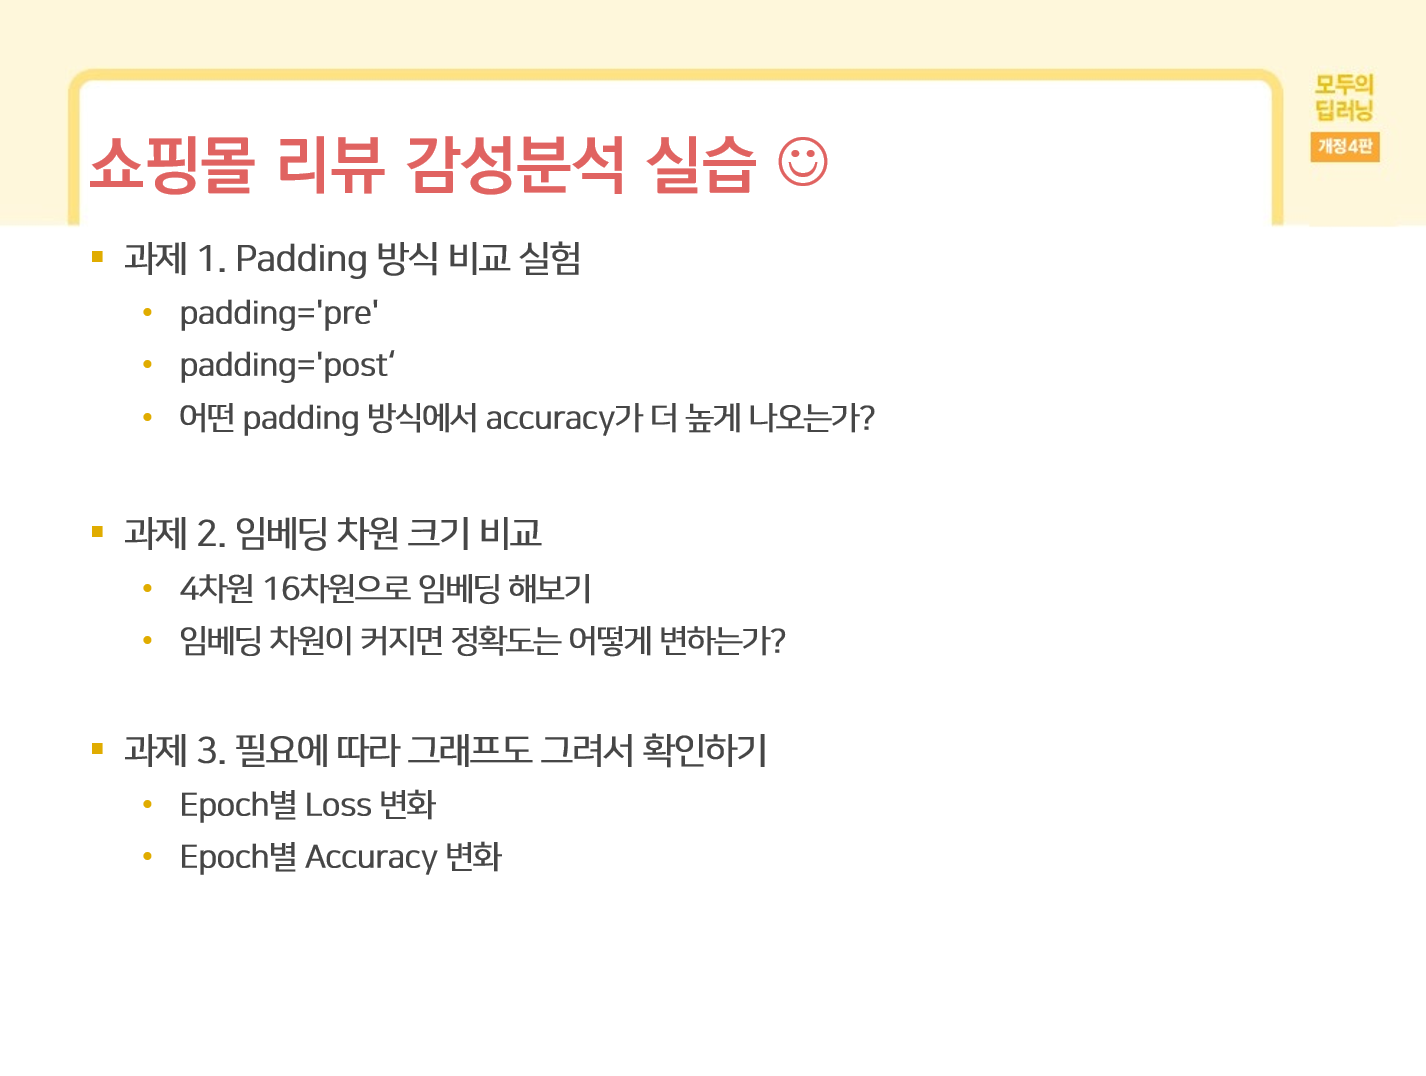

In [76]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Dense, Flatten
from tensorflow.keras.models import Sequential
from numpy import array

In [77]:
texts = [
# ✅ 긍정 리뷰 (1)
"배송이 정말 빨라서 놀랐어요 제품 포장도 꼼꼼했고 상태도 아주 좋았습니다",
"생각보다 퀄리티가 좋아서 만족해요 가격 대비 훌륭합니다",
"디자인도 예쁘고 사용하기도 편해서 재구매 의사 있어요",
"아이 선물로 샀는데 너무 좋아해서 만족합니다",
"후기 보고 샀는데 후기 그대로라 믿음이 가네요",
"화면에서 보던 그대로 와서 실망이 없었어요",
"가성비가 좋아서 다음에도 여기서 구매하려고요",
"설명대로 제품이 와서 신뢰가 갑니다",
"마감도 깔끔하고 사용감도 좋아요",
"배송 중 파손 걱정했는데 포장이 완벽했어요",
"생각보다 사이즈가 커서 더 좋았어요",
"재질이 좋아서 오래 쓸 수 있을 것 같아요",
"가격 대비 퀄리티가 정말 좋아요",
"처음 써보는데 사용법도 간단해서 좋네요",
"아이 피부에 닿는 제품인데 안심하고 쓸 수 있어요",
"사진보다 실물이 더 예뻐요",
"색감이 마음에 들어서 만족합니다",
"선물용으로 샀는데 받는 사람이 좋아했어요",
"배송도 빠르고 문의 답변도 친절했어요",
"여러 개 사길 잘했다는 생각이 들어요",
"기대 안 했는데 생각보다 훨씬 좋아요",
"소음도 거의 없고 성능도 만족스럽습니다",
"매일 사용 중인데 불편함 없이 잘 쓰고 있어요",
"구성품도 알차고 가격도 괜찮아요",
"설치도 쉽고 설명서도 잘 되어 있어요",
"이 가격에 이 정도면 충분히 만족합니다",
"디자인이 깔끔해서 어디에 두어도 잘 어울려요",
"아이도 저도 모두 만족한 제품이에요",
"재구매 확정입니다",
"친구 추천으로 샀는데 잘 산 것 같아요",
"오래 고민하다 샀는데 후회 없어요",
"기능이 다양해서 활용도가 높아요",
"제품 상태가 아주 깨끗하게 왔어요",
"기대 이상이라 기분 좋네요",
"배송 일정도 정확해서 좋았습니다",
"세일할 때 사서 더 만족해요",
"색상 선택 잘한 것 같아요",
"실용적이라서 자주 쓰게 됩니다",
"사용해보니 왜 인기 있는지 알겠어요",
"품질이 좋아서 선물하기 좋네요",
"아이 교육용으로 딱이에요",
"집에서 쓰기 정말 편리해요",
"재질이 부드럽고 마감이 좋아요",
"전체적으로 만족스러운 구매였습니다",
"설명과 실제 제품이 동일해서 좋았어요",
"빠른 배송 덕분에 바로 사용할 수 있었어요",
"가격 대비 만족도가 높아요",
"다음에도 같은 브랜드로 살 것 같아요",
"가성비 있게 잘 산 것 같아요",
"조립도 간편하고 생각했던 것보다 훨씬 튼튼해요",

# ❌ 부정 리뷰 (0)
"생각보다 품질이 별로라서 실망했어요",
"사진이랑 너무 달라서 당황했습니다",
"배송이 너무 늦어서 불편했어요",
"포장이 허술해서 제품이 손상되어 왔어요",
"가격 대비 퀄리티가 떨어집니다",
"몇 번 쓰지도 않았는데 고장이 났어요",
"설명과 다른 제품이 와서 실망이에요",
"사이즈가 너무 작아서 쓸 수가 없어요",
"마감 처리가 너무 조잡해요",
"소음이 심해서 사용하기 힘들어요",
"색상이 화면이랑 완전 달라요",
"기대하고 샀는데 실망이 큽니다",
"제품 상태가 좋지 않았어요",
"사용법이 너무 불편해요",
"내구성이 약한 것 같아요",
"아이한테 쓰기엔 좀 불안합니다",
"재질이 너무 저렴해 보여요",
"설치가 너무 어려워요",
"설명서가 부실해서 이해하기 힘들어요",
"한 번 쓰고 나서 다시는 안 쓰게 되네요",
"생각보다 무겁고 불편해요",
"가격만 비싸고 성능은 별로에요",
"배송 중 문제가 있었는지 흠집이 많아요",
"고객센터 응대가 별로였어요",
"후기 믿고 샀는데 후회됩니다",
"기능이 기대 이하에요",
"사진만 예쁘고 실제는 별로에요",
"조립하다가 부품이 부러졌어요",
"사용 중 계속 오류가 나요",
"불량 제품을 받은 것 같아요",
"다른 제품 살 걸 그랬어요",
"아이 반응이 별로라 아쉽네요",
"생각보다 냄새가 심해요",
"재구매 의사 없습니다",
"설명보다 성능이 떨어져요",
"배송 상태가 너무 엉망이었어요",
"마감이 너무 허술합니다",
"가격 대비 실망스러워요",
"기대했던 기능이 제대로 안 돼요",
"사용할수록 불편함이 느껴져요",
"디자인은 괜찮은데 성능이 별로에요",
"제품이 너무 약해 보여요",
"한 달도 안 돼서 고장났어요",
"환불하고 싶을 정도에요",
"배송 일정이 계속 밀렸어요",
"상담 응답이 너무 늦어요",
"포장이 거의 안 되어 있었어요",
"전체적으로 만족도가 낮아요",
"다시는 구매하지 않을 것 같아요",
"품질 관리가 전혀 안 되는 것 같아 실망스럽습니다"
]

labels = array([
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
])

In [78]:
token = Tokenizer()
token.fit_on_texts(texts)

print(token.word_index)

x = token.texts_to_sequences(texts)
print('\n리뷰 텍스트, 토큰화 결과:\n', x)

word_size = len(token.word_index) + 1
max_len = 8 #word_size보다는 여유있게 잡기

{'너무': 1, '것': 2, '같아요': 3, '샀는데': 4, '생각보다': 5, '배송': 6, '안': 7, '가격': 8, '대비': 9, '제품이': 10, '잘': 11, '제품': 12, '좋아서': 13, '있어요': 14, '아이': 15, '좋아요': 16, '정말': 17, '퀄리티가': 18, '재구매': 19, '만족합니다': 20, '후기': 21, '와서': 22, '중': 23, '포장이': 24, '더': 25, '재질이': 26, '쓸': 27, '수': 28, '좋네요': 29, '기대': 30, '기능이': 31, '상태가': 32, '별로에요': 33, '배송이': 34, '아주': 35, '좋았습니다': 36, '만족해요': 37, '예쁘고': 38, '의사': 39, '실망이': 40, '다음에도': 41, '사이즈가': 42, '좋았어요': 43, '오래': 44, '훨씬': 45, '거의': 46, '사용': 47, '쓰고': 48, '되어': 49, '이': 50, '산': 51, '없어요': 52, '높아요': 53, '왔어요': 54, '쓰게': 55, '품질이': 56, '마감이': 57, '전체적으로': 58, '설명과': 59, '있었어요': 60, '만족도가': 61, '살': 62, '번': 63, '다른': 64, '힘들어요': 65, '불편해요': 66, '보여요': 67, '한': 68, '다시는': 69, '계속': 70, '성능이': 71, '빨라서': 72, '놀랐어요': 73, '포장도': 74, '꼼꼼했고': 75, '상태도': 76, '훌륭합니다': 77, '디자인도': 78, '사용하기도': 79, '편해서': 80, '선물로': 81, '좋아해서': 82, '보고': 83, '그대로라': 84, '믿음이': 85, '가네요': 86, '화면에서': 87, '보던': 88, '그대로': 89, '없었어요': 90, '가성비가': 91, '여기서': 92, '구매하려고요': 93, 

In [79]:
x_pre = pad_sequences(x, maxlen=max_len, padding='pre')
x_post = pad_sequences(x, maxlen=max_len, padding='post')
print('\nx_pre 패딩 결과:\n', x_pre)
print('\nx_post 패딩 결과:\n', x_post)


x_pre 패딩 결과:
 [[ 72  73  12  74  75  76  35  36]
 [  0   5  18  13  37   8   9  77]
 [  0  78  38  79  80  19  39  14]
 [  0   0  15  81   4   1  82  20]
 [  0  21  83   4  21  84  85  86]
 [  0   0  87  88  89  22  40  90]
 [  0   0   0  91  13  41  92  93]
 [  0   0   0  94  10  22  95  96]
 [  0   0   0   0  97  98  99  16]
 [  0   0   6  23 100 101  24 102]
 [  0   0   0   5  42 103  25  43]
 [ 26  13  44  27  28 104   2   3]
 [  0   0   0   8   9  18  17  16]
 [  0   0   0 105 106 107 108  29]
 [ 15 109 110 111 112  27  28  14]
 [  0   0   0   0 113 114  25 115]
 [  0   0   0   0 116 117 118  20]
 [  0   0   0 119   4 120 121 122]
 [  0   0   0 123 124 125 126 127]
 [  0   0 128 129 130 131 132 133]
 [  0   0  30   7 134   5  45  16]
 [  0   0   0 135  46 136 137 138]
 [139  47 140 141 142  11  48  14]
 [  0   0   0   0 143 144 145 146]
 [  0   0 147 148 149  11  49  14]
 [  0   0  50 150  50 151 152  20]
 [  0   0 153 154 155 156  11 157]
 [  0   0   0 158 159 160 161 162]
 [  0

In [80]:
def build_model():
    model = Sequential()
    model.add(Embedding(word_size, 8, input_length=max_len))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    model.summary()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [81]:
model_pre = build_model()
model_pre.fit(x_pre, labels, epochs=20, verbose=0) # 과정 생략을 위해 verbose=0
acc_pre = model_pre.evaluate(x_pre, labels, verbose=0)[1]

model_post = build_model()
model_post.fit(x_post, labels, epochs=20, verbose=0)
acc_post = model_post.evaluate(x_post, labels, verbose=0)[1]

print("\n" + "="*30)
print(f"Pre Padding Accuracy:  {acc_pre:.4f}")
print(f"Post Padding Accuracy: {acc_post:.4f}")
print("="*30)

print("\n[Pre Padding 예시]:\n", x_pre[0])
print("[Post Padding 예시]:\n", x_post[0])

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Pre Padding Accuracy:  0.9700
Post Padding Accuracy: 0.9900

[Pre Padding 예시]:
 [72 73 12 74 75 76 35 36]
[Post Padding 예시]:
 [72 73 12 74 75 76 35 36]


In [82]:
def build_model_dim(dimentions):
    model = Sequential()
    model.add(Embedding(word_size, dimentions, input_length=max_len))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    model.summary()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [84]:
model_4 = build_model_dim(4)
model_4.fit(x_pre, labels, epochs=50, verbose=0) # 과정 생략을 위해 verbose=0, epochs 20 -> 50 증가
acc_4 = model_4.evaluate(x_pre, labels, verbose=0)[1]

model_16 = build_model_dim(16)
model_16.fit(x_pre, labels, epochs=50, verbose=0) # 과정 생략을 위해 verbose=0, epochs 20 -> 50 증가
acc_16 = model_16.evaluate(x_pre, labels, verbose=0)[1]

print("\n" + "="*30)
print(f"Embedding Dim 4 Accuracy:  {acc_4:.4f}")
print(f"Embedding Dim 16 Accuracy: {acc_16:.4f}")
print("="*30)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Embedding Dim 4 Accuracy:  0.9800
Embedding Dim 16 Accuracy: 0.9900


In [85]:
import matplotlib.pyplot as plt

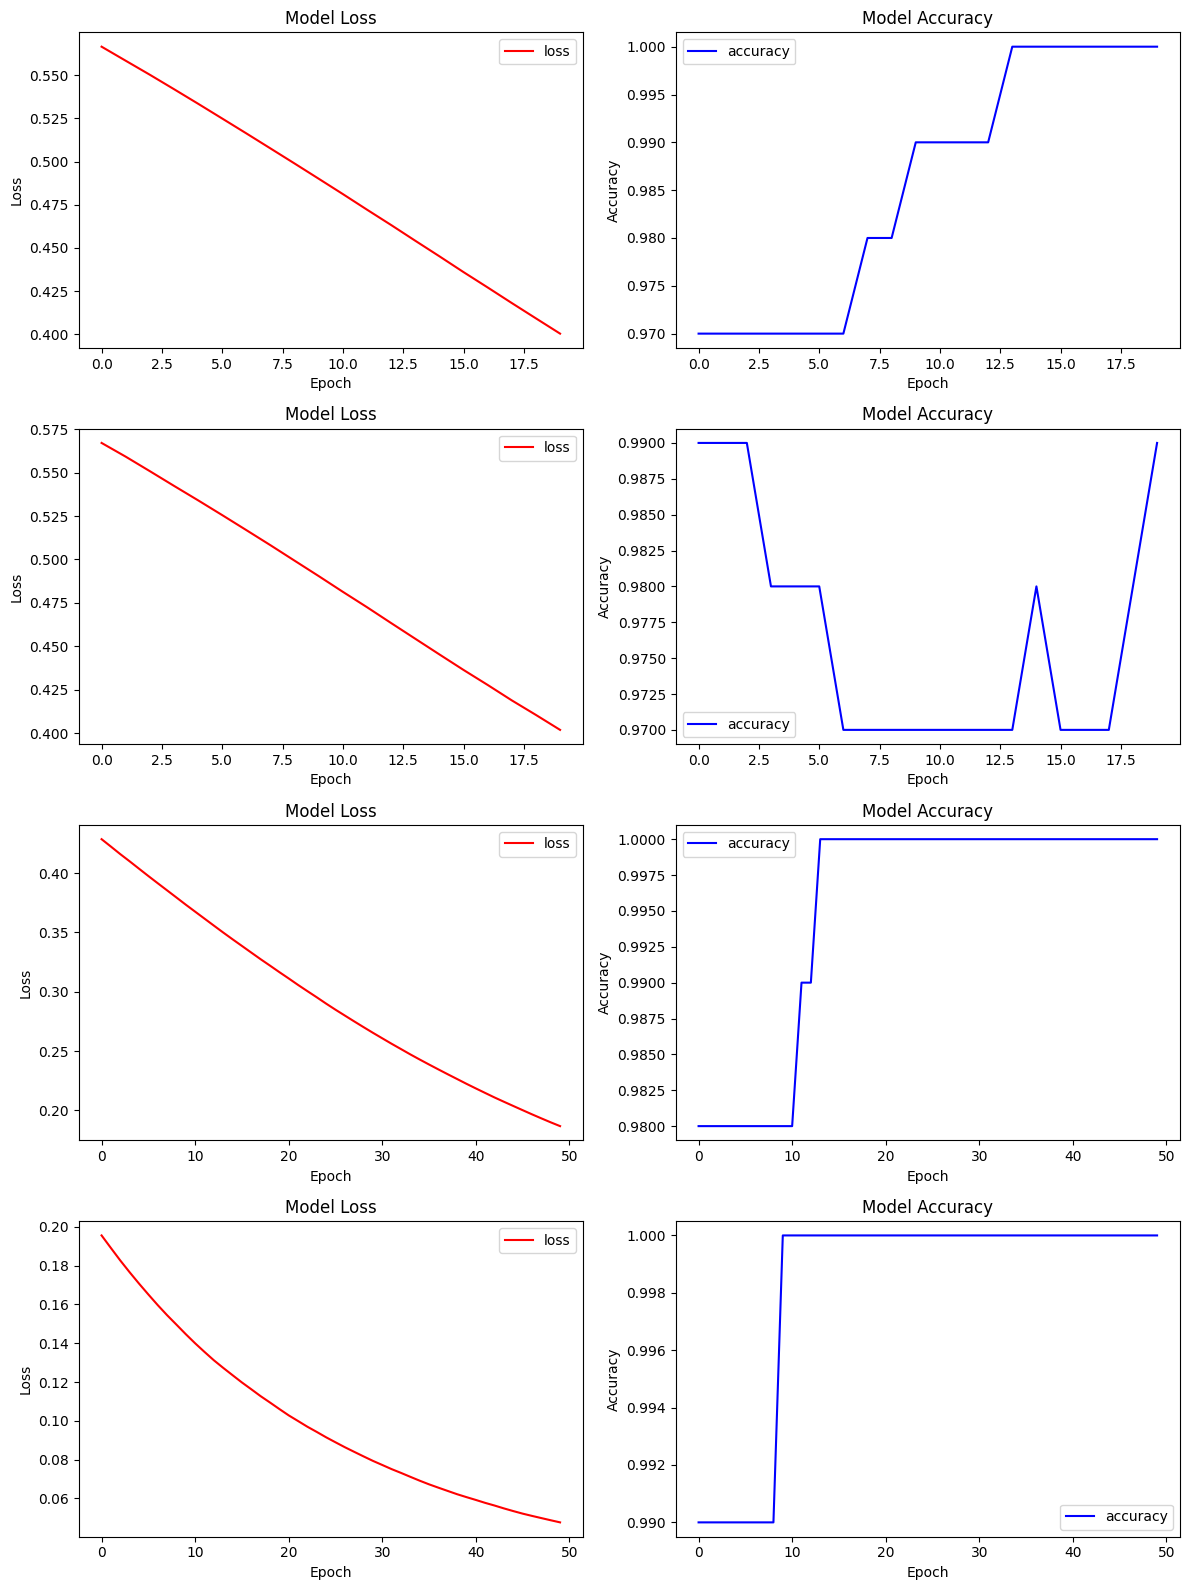

In [86]:
plt.figure(figsize=(12, 16))

history = model_pre.fit(x_pre, labels, epochs=20, verbose=0)

plt.subplot(4, 2, 1)
plt.plot(history.history['loss'], 'r-', label='loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

history = model_post.fit(x_post, labels, epochs=20, verbose=0)

plt.subplot(4, 2, 3)
plt.plot(history.history['loss'], 'r-', label='loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(4, 2, 4)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

history = model_4.fit(x_pre, labels, epochs=50, verbose=0)

plt.subplot(4, 2, 5)
plt.plot(history.history['loss'], 'r-', label='loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(4, 2, 6)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

history = model_16.fit(x_pre, labels, epochs=50, verbose=0)

plt.subplot(4, 2, 7)
plt.plot(history.history['loss'], 'r-', label='loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(4, 2, 8)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Q1. padding 방식 실험
 - 첫째 줄의 pre 방식과 둘째 줄의 post 방식의 비교를 통해 padding이 위치하는 바에 따라 결과가 달라질 수 있음을 알 수 있다. 
 - pre 방식과 post 방식의 accuracy 예>
 '''==============================
    Pre Padding Accuracy:  0.9700
    Post Padding Accuracy: 0.9900
    =============================='''

Q2. 임베딩 차원 크기 비교
 - 세 번째 줄의 4차원 임베딩과 네 번째 줄의 16차원 임베딩 비교를 통해 임베딩 차원이 커질수록 정확도가 상승하는 방향임을 알 수 있다.
 - 현재로서는 크게 차이나지 않으나, 여러 번 반복해서 accuracy 비교를 시행하면 대체로 16차원 임베딩한 결과물이 accuracy가 더 높다.
 '''==============================
    Embedding Dim 4 Accuracy:  0.9800
    Embedding Dim 16 Accuracy: 0.9900
    =============================='''

## Q2. 뉴스 카테고리 분류

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [1]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(
    subset='all',        # 전체 데이터
    remove=('headers', 'footers', 'quotes')  # 불필요한 메타데이터 제거
)

X = data.data      # 뉴스 텍스트 (리스트)
y = data.target    # 라벨 (정수)

In [3]:
# 1. 데이터 토큰화 및 패딩
max_words = 10000  # 가장 빈도수 높은 10,000개 단어 사용
max_len = 100      # 한 뉴스당 단어 수를 100개로 제한

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)

# padding='pre' 방식으로 길이를 맞춤
X_padded = pad_sequences(sequences, maxlen=max_len)
y = np.array(y)
num_classes = len(np.unique(y)) # 뉴스 카테고리 개수 (20개)

In [4]:
def build_lstm_model(embed_dim, use_dropout=False):
    model = Sequential()
    model.add(Embedding(max_words, embed_dim, input_length=max_len))
    
    # 2번 문항: 모델 구조 비교 (LSTM만 vs LSTM + Dropout)
    if use_dropout:
        model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2)) # LSTM 내부 및 레이어 간 드롭아웃
        model.add(Dropout(0.5))
    else:
        model.add(LSTM(64))
        
    model.add(Dense(num_classes, activation='softmax')) # 다중 분류이므로 softmax
    
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [7]:
# 50차원 vs 100차원 (Dropout 미적용 상태로 비교)
hist_50 = build_lstm_model(50).fit(X_padded, y, epochs=20, batch_size=128, validation_split=0.2, verbose=1)
hist_100 = build_lstm_model(100).fit(X_padded, y, epochs=20, batch_size=128, validation_split=0.2, verbose=1)

print(f"50차원 검증 정확도: {max(hist_50.history['val_accuracy']):.4f}")
print(f"100차원 검증 정확도: {max(hist_100.history['val_accuracy']):.4f}")

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.1014 - loss: 2.8385 - val_accuracy: 0.1782 - val_loss: 2.5779
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.2133 - loss: 2.3624 - val_accuracy: 0.1748 - val_loss: 2.3534
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.2759 - loss: 2.1226 - val_accuracy: 0.2902 - val_loss: 2.1319
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.3592 - loss: 1.8668 - val_accuracy: 0.3241 - val_loss: 1.9734
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.4695 - loss: 1.5874 - val_accuracy: 0.4034 - val_loss: 1.8243
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5394 - loss: 1.3819 - val_accuracy: 0.4167 - val_loss: 1.7991
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6057 - loss: 1.1781 - val_accuracy: 0.4676 - val_loss: 1.7094
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6610 - loss: 1.0456 - val_accu

In [8]:
# 임베딩 100으로 고정 후 비교
hist_no_drop = build_lstm_model(100, use_dropout=False).fit(X_padded, y, epochs=20, batch_size=128, validation_split=0.2, verbose=0)
hist_with_drop = build_lstm_model(100, use_dropout=True).fit(X_padded, y, epochs=20, batch_size=128, validation_split=0.2, verbose=0)

print(f"50차원 검증 정확도: {max(hist_no_drop.history['val_accuracy']):.4f}")
print(f"100차원 검증 정확도: {max(hist_with_drop.history['val_accuracy']):.4f}")

50차원 검증 정확도: 0.5987
100차원 검증 정확도: 0.5894


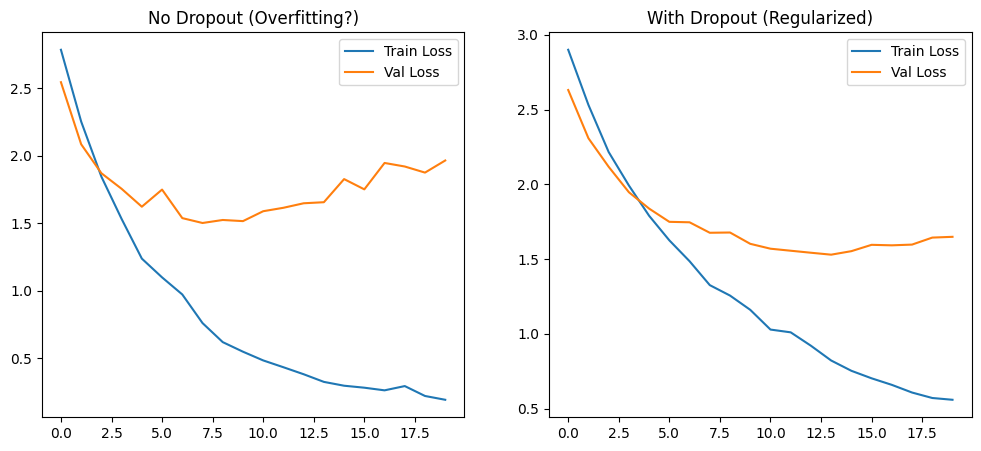

In [9]:
def plot_overfitting(hist1, hist2, title1, title2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(hist1.history['loss'], label='Train Loss')
    plt.plot(hist1.history['val_loss'], label='Val Loss')
    plt.title(title1)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist2.history['loss'], label='Train Loss')
    plt.plot(hist2.history['val_loss'], label='Val Loss')
    plt.title(title2)
    plt.legend()
    plt.show()

plot_overfitting(hist_no_drop, hist_with_drop, "No Dropout (Overfitting?)", "With Dropout (Regularized)")